# Results from the ML model

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

In [19]:
def load_predictions(event: str):
    """
    Loads MET_pt_pred, MET_pt (reco) and GenMET_pt from the parquet
    saved by predict_on_dataset.

    Parameters:
        event      : str — dataset/event label (e.g. "DYJetsToLL")
        output_dir : str — directory where the parquet was saved

    Returns:
        Y_pred  : np.ndarray        — NN-predicted MET_pt
        y_true_GeV  : np.ndarray | None — GenMET_pt (ground truth)
        MET_pt      : np.ndarray | None — reconstructed MET_pt
    """
    parquet_path = os.path.join(f"predictions_testing_{event}.parquet")

    if not os.path.exists(parquet_path):
        raise FileNotFoundError(f"Parquet not found: {parquet_path}")

    df = pd.read_parquet(parquet_path)

    if "MET_pt_pred" not in df.columns:
        raise ValueError(f"Column 'MET_pt_pred' missing in {parquet_path}")

    Y_pred = df["MET_pt_pred"].to_numpy()
    y_true = df["GenMET_pt"].to_numpy() if "GenMET_pt" in df.columns else None
    MET_pt     = df["MET_pt"].to_numpy()    if "MET_pt"    in df.columns else None

    if y_true is None:
        print(f"  [WARNING] 'GenMET_pt' not found in {parquet_path}")
    if MET_pt is None:
        print(f"  [WARNING] 'MET_pt' not found in {parquet_path}")

    print(f"  Loaded {len(df):,} events from '{parquet_path}'")
    print(f"  Columns found: {list(df.columns)}")

    return Y_pred, y_true, MET_pt

In [20]:
def _compute_metrics(Y_pred, y_true, MET_pt, label):
    rmse_reco = np.sqrt(mean_squared_error(y_true, MET_pt))
    mae_reco  = mean_absolute_error(y_true, MET_pt)
    r2_reco   = r2_score(y_true, MET_pt)

    print(f"Reconstruction performance for {label}:")
    print(f"    RMSE = {rmse_reco:.4f} GeV")
    print(f"    MAE  = {mae_reco:.4f} GeV")
    print(f"    R²   = {r2_reco:.4f}")

    rmse_pred = np.sqrt(mean_squared_error(y_true, Y_pred))
    mae_pred  = mean_absolute_error(y_true, Y_pred)
    r2_pred   = r2_score(y_true, Y_pred)

    print(f"ML model performance for {label}:")
    print(f"    RMSE = {rmse_pred:.4f} GeV")
    print(f"    MAE  = {mae_pred:.4f} GeV")
    print(f"    R²   = {r2_pred:.4f}")

    DELTA_rmse     = rmse_reco - rmse_pred
    DELTA_mae      = mae_reco  - mae_pred
    DELTA_r2       = r2_pred   - r2_reco

    print(f"Performance improvement for {label}:")
    print(f"    DELTA_RMSE = {DELTA_rmse:.4f} GeV")
    print(f"    DELTA_MAE  = {DELTA_mae:.4f} GeV")
    print(f"    DELTA_R²   = {DELTA_r2:.4f}")

    pct_rmse = DELTA_rmse / rmse_reco * 100
    pct_mae  = DELTA_mae  / mae_reco  * 100
    pct_r2   = DELTA_r2   / abs(r2_reco) * 100 if r2_reco != 0 else float("nan")

    print(f"Performance relative improvement for {label}:")
    print(f"    DELTA_RMSE = {pct_rmse:+.2f}%")
    print(f"    DELTA_MAE  = {pct_mae:+.2f}%")
    print(f"    DELTA_R²   = {pct_r2:+.2f}%")
    return

In [21]:
def _plot_fold_learning_curves(df_folds):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"CV Fold Learning Curves", fontsize=13, fontweight="bold")
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for fh in df_folds.groupby("fold"):
        fold_idx, df = fh
        c = colors[(fold_idx - 1) % len(colors)]
        axes[0].plot(df["epoch"], df["loss"],     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[0].plot(df["epoch"], df["val_loss"], color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")
        axes[1].plot(df["epoch"], df["loss"].pow(0.5),     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[1].plot(df["epoch"], df["val_loss"].pow(0.5), color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")

    for ax, ylabel, title in zip(axes, ["MSE", "RMSE"], ["Loss (MSE)", "RMSE"]):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

In [22]:
def _plot_learning_curves(df_lc):
    epochs  = range(1, len(df_lc) + 1)
    has_val = "val_loss" in df_lc.columns
    has_mse = "mse" in df_lc.columns

    fig, axes = plt.subplots(1, 2 if has_mse else 1, figsize=(14 if has_mse else 7, 5))
    if not has_mse:
        axes = [axes]
    fig.suptitle(f"Learning Curves", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, df_lc["loss"], color="red", lw=1.5, label="Train loss")
    if has_val:
        axes[0].plot(epochs, df_lc["val_loss"], color="blue", lw=1.5, label="Val loss")
    axes[0].set_title("Loss (MSE)", fontsize=11)
    axes[0].set_xlabel("Epoch", fontsize=10)
    axes[0].set_ylabel("MSE", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # RMSE
    if has_mse:
        axes[1].plot(epochs, df_lc["mse"].pow(0.5), color="red", lw=1.5, label="Train RMSE")
        if has_val:
            axes[1].plot(epochs, df_lc["val_mse"].pow(0.5), color="blue", lw=1.5, label="Val RMSE")
        axes[1].set_title("RMSE metric", fontsize=11)
        axes[1].set_xlabel("Epoch", fontsize=10)
        axes[1].set_ylabel("RMSE", fontsize=10)
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Learning curves:")
    print(f"    Epochs run       : {len(df_lc)}")
    print(f"    Final train loss : {df_lc['loss'].iloc[-1]:.4f}")
    if has_val:
        print(f"    Final val loss   : {df_lc['val_loss'].iloc[-1]:.4f}")
        print(f"    Best val loss    : {df_lc['val_loss'].min():.4f}  "
              f"(epoch {df_lc['val_loss'].idxmin() + 1})")
    return

In [23]:
def _scatterplot_reco_vs_gen(met_pt: np.ndarray, y_true_GeV: np.ndarray, event: str, color: str):
    """
        Scatter plot of Reconstructed MET_pt vs GenMET_pt.

        Parameters:
            met_pt      : np.ndarray — reconstructed MET_pt values
            y_true_GeV  : np.ndarray — GenMET_pt (ground truth) values
            event       : str        — dataset/event label for title and filename
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(y_true_GeV, met_pt, alpha=0.3, s=8, color=color, rasterized=True)

    # identity line y = x
    lims = [
        min(y_true_GeV.min(), met_pt.min()),
        max(y_true_GeV.max(), met_pt.max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x")

    r2   = r2_score(y_true_GeV, met_pt)
    rmse = np.sqrt(mean_squared_error(y_true_GeV, met_pt))
    ax.text(0.05, 0.92, f"RMSE = {rmse:.2f} GeV\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_xlabel("GenMET_pt [GeV]", fontsize=12)
    ax.set_ylabel("Reconstructed MET_pt [GeV]", fontsize=12)
    ax.set_title(f"Reco MET vs Gen MET — {event}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    plt.tight_layout()
    plt.show()
    return

In [24]:
def _scatterplot_pred_vs_gen(y_pred_GeV: np.ndarray, y_true_GeV: np.ndarray, event: str, color: str):
    """
        Scatter plot of Predicted MET_pt vs GenMET_pt.

        Parameters:
            y_pred_GeV  : np.ndarray — NN-predicted MET_pt values
            y_true_GeV  : np.ndarray — GenMET_pt (ground truth) values
            event       : str        — dataset/event label for title and filename
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(y_true_GeV, y_pred_GeV, alpha=0.3, s=8, color=color, rasterized=True)

    # identity line y = x
    lims = [
        min(y_true_GeV.min(), y_pred_GeV.min()),
        max(y_true_GeV.max(), y_pred_GeV.max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x")

    r2   = r2_score(y_true_GeV, y_pred_GeV)
    rmse = np.sqrt(mean_squared_error(y_true_GeV, y_pred_GeV))
    ax.text(0.05, 0.92, f"RMSE = {rmse:.2f} GeV\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_xlabel("GenMET_pt [GeV]", fontsize=12)
    ax.set_ylabel("Predicted MET_pt [GeV]", fontsize=12)
    ax.set_title(f"Predicted MET vs Gen MET — {event}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    plt.tight_layout()
    plt.show()
    return

In [25]:
def _residuals_plots(y_pred_GeV: np.ndarray, y_true_GeV: np.ndarray,
                   MET_pt: np.ndarray, event: str):
    """
    Residual plots for both predicted and reconstructed MET vs GenMET.
    Residual defined as (MET_pred - GenMET) and (MET_reco - GenMET).

    Produces a figure with two panels side by side:
      - Left : histogram of residuals for pred and reco overlaid
      - Right: residual vs GenMET_pt scatter (pred and reco overlaid)

    Parameters:
        y_pred_GeV : np.ndarray — NN-predicted MET_pt values
        y_true_GeV : np.ndarray — GenMET_pt (ground truth) values
        met_pt     : np.ndarray — reconstructed MET_pt values
        event      : str        — dataset/event label for title and filename
        output_dir : str        — directory where the PNG is saved
    """
    res_pred = y_pred_GeV - y_true_GeV
    res_reco = MET_pt     - y_true_GeV

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Residuals — {event}", fontsize=14, fontweight="bold")

    # --- Left: residual histogram ---
    bins = np.linspace(
        min(res_pred.min(), res_reco.min()),
        max(res_pred.max(), res_reco.max()),
        80
    )
    axes[0].hist(res_pred, bins=bins, alpha=0.6, color="darkorange",
                 label=f"Pred  (μ={res_pred.mean():.2f}, σ={res_pred.std():.2f})")
    axes[0].hist(res_reco, bins=bins, alpha=0.6, color="steelblue",
                 label=f"Reco  (μ={res_reco.mean():.2f}, σ={res_reco.std():.2f})")
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
    axes[0].set_xlabel("MET - GenMET [GeV]", fontsize=12)
    axes[0].set_ylabel("Events", fontsize=12)
    axes[0].set_title("Residual distribution", fontsize=12)
    axes[0].legend(fontsize=9)

    # --- Right: residual vs GenMET scatter ---
    axes[1].scatter(y_true_GeV, res_pred, alpha=0.2, s=6,
                    color="darkorange", label="Pred", rasterized=True)
    axes[1].scatter(y_true_GeV, res_reco, alpha=0.2, s=6,
                    color="steelblue", label="Reco", rasterized=True)
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1.2)
    axes[1].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[1].set_ylabel("MET - GenMET [GeV]", fontsize=12)
    axes[1].set_title("Residual vs GenMET", fontsize=12)
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return

In [26]:
def _response_plots(y_pred_GeV: np.ndarray, y_true_GeV: np.ndarray,
                  MET_pt: np.ndarray, event: str, max_scatter_points: int = 10000):
    """
        Response plots: MET / GenMET vs GenMET for both predicted and reconstructed.
        A perfect estimator sits at response = 1 for all GenMET values.

        Produces a figure with two panels side by side:
        - Left : histogram of response for pred and reco overlaid
        - Right: response vs GenMET_pt scatter (pred and reco overlaid)

        Parameters:
       
        y_pred_GeV : np.ndarray — NN-predicted MET_pt values
        y_true_GeV : np.ndarray — GenMET_pt (ground truth) values
        MET_pt     : np.ndarray — reconstructed MET_pt values
        event      : str        — dataset/event label for title and filename
        max_scatter_points: int        — max events shown in scatter (default 5000)
    """
    # avoid division by zero
    mask       = y_true_GeV > 0
    resp_pred  = y_pred_GeV[mask] / y_true_GeV[mask]
    resp_reco  = MET_pt[mask]     / y_true_GeV[mask]
    gen_masked = y_true_GeV[mask]

    # subsample for scatter only
    n_total = len(gen_masked)
    if n_total > max_scatter_points:
        idx = np.random.choice(n_total, size=max_scatter_points, replace=False)
    else:
        idx = np.arange(n_total)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Response (MET/GenMET_pt) — {event}", fontsize=14, fontweight="bold")

    # Left: response histogram (all events)
    bins = np.linspace(0, 3, 80)

    mu_pred, sig_pred = resp_pred.mean(), resp_pred.std()
    mu_reco, sig_reco = resp_reco.mean(), resp_reco.std()

    axes[0].hist(resp_pred, bins=bins, alpha=0.6, color="darkorange",
                 label=f"Pred  (μ={mu_pred:.2e}, σ={sig_pred:.2e})")
    axes[0].hist(resp_reco, bins=bins, alpha=0.6, color="steelblue",
                 label=f"Reco  (μ={mu_reco:.2e}, σ={sig_reco:.2e})")
    axes[0].axvline(1, color="red", linestyle="--", linewidth=1.2, label="ideal = 1")
    axes[0].set_xlabel("MET/GenMET_pt", fontsize=12)
    axes[0].set_ylabel("Events", fontsize=12)
    axes[0].set_title("Response distribution", fontsize=12)
    axes[0].legend(fontsize=9)

    # Right: response vs GenMET scatter (subsampled)
    axes[1].scatter(gen_masked[idx], resp_pred[idx], alpha=0.4, s=8,
                    color="darkorange", label=f"Pred (n={len(idx):,})", rasterized=True)
    axes[1].scatter(gen_masked[idx], resp_reco[idx], alpha=0.4, s=8,
                    color="steelblue",  label=f"Reco (n={len(idx):,})", rasterized=True)
    axes[1].axhline(1, color="red", linestyle="--", linewidth=1.2, label="ideal = 1")
    axes[1].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[1].set_ylabel("MET/GenMET_pt", fontsize=12)
    axes[1].set_title(f"Response vs GenMET", fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 4)

    plt.tight_layout()
    plt.show()
    return

In [27]:
def _profile_histogram(y_pred: np.ndarray, y_true: np.ndarray,
                       met_pt: np.ndarray, event: str,
                       bin_width: float = 10.0,
                       min_counts: int = 10):
    """
    Profile histogram: mean and std of MET_pred, MET_reco, GenMET
    as a function of GenMET_pt bins.

    For each bin in GenMET_pt, computes:
      - mean  → plotted as the central value
      - std   → plotted as error bars

    Bins with fewer than min_counts events are excluded.
    The x-axis is clipped at the last bin with sufficient statistics.

    Parameters:
        y_pred      : np.ndarray — NN-predicted MET_pt values
        y_true      : np.ndarray — GenMET_pt (ground truth) values
        met_pt      : np.ndarray — reconstructed MET_pt values
        event       : str        — dataset/event label for title and filename
        bin_width   : float      — bin width in GeV (default 10 GeV)
        min_counts  : int        — minimum events per bin to plot (default 10)
    """
    x_max  = np.ceil(y_true.max() / bin_width) * bin_width
    n_bins = int(x_max / bin_width)
    bins   = np.linspace(0, x_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_indices = np.clip(np.digitize(y_true, bins) - 1, 0, n_bins - 1)

    # count events per bin on y_true to find the last well-populated bin
    counts_true = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        counts_true[i] = (bin_indices == i).sum()

    last_valid_bin = np.max(np.where(counts_true >= min_counts)[0])
    x_plot_max = bins[last_valid_bin + 1]

    print(f"  Plotting up to {x_plot_max:.0f} GeV "
          f"(last bin with >= {min_counts} events: "
          f"[{bins[last_valid_bin]:.0f}, {bins[last_valid_bin+1]:.0f}] GeV, "
          f"n={counts_true[last_valid_bin]})")

    arrays  = {"GenMET": y_true, "MET pred": y_pred, "MET reco": met_pt}
    colors  = {"GenMET": "black", "MET pred": "darkorange", "MET reco": "steelblue"}
    markers = {"GenMET": "s",     "MET pred": "o",          "MET reco": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Profile Histogram — {event}", fontsize=14, fontweight="bold")

    for label, arr in arrays.items():
        means  = np.full(n_bins, np.nan)
        stds   = np.full(n_bins, np.nan)
        counts = np.zeros(n_bins, dtype=int)

        for i in range(n_bins):
            mask      = (bin_indices == i)
            counts[i] = mask.sum()
            if counts[i] >= min_counts:
                means[i] = arr[mask].mean()
                stds[i]  = arr[mask].std()

        valid = (counts >= min_counts) & (bin_centers <= x_plot_max)

        axes[0].errorbar(
            bin_centers[valid], means[valid], yerr=stds[valid],
            fmt=markers[label], color=colors[label], label=label,
            markersize=5, capsize=3, linewidth=1.2
        )
        axes[1].plot(
            bin_centers[valid], stds[valid],
            marker=markers[label], color=colors[label],
            label=label, markersize=5, linewidth=1.2
        )

    axes[0].plot([0, x_plot_max], [0, x_plot_max], "r--", linewidth=1.2, label="ideal")
    axes[0].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[0].set_ylabel("Mean MET [GeV]", fontsize=12)
    axes[0].set_title("Mean vs GenMET_pt", fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].set_xlim(0, x_plot_max)

    axes[1].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[1].set_ylabel("Std MET [GeV]", fontsize=12)
    axes[1].set_title("Resolution (std) vs GenMET_pt", fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].set_xlim(0, x_plot_max)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return

In [28]:
def _profile_histogram_response(y_pred: np.ndarray, y_true: np.ndarray,
                                 met_pt: np.ndarray, event: str,
                                 n_bins: int = 30,
                                 min_counts: int = 10,
                                 min_gen: float = 1.0):
    """
    Profile histogram of the response (MET / GenMET) vs GenMET_pt
    using logarithmic bins to handle the steeply falling distribution.

    Logarithmic binning ensures:
      - fine granularity at low GenMET_pt where statistics are high
      - wider bins at high GenMET_pt where statistics are scarce
      - avoidance of near-zero division by starting from min_gen

    Parameters:
        y_pred      : np.ndarray — NN-predicted MET_pt values
        y_true      : np.ndarray — GenMET_pt (ground truth) values
        met_pt      : np.ndarray — reconstructed MET_pt values
        event       : str        — dataset/event label for title and filename
        n_bins      : int        — number of log bins (default 30)
        min_counts  : int        — minimum events per bin to plot (default 10)
        min_gen     : float      — minimum GenMET_pt in GeV to start binning (default 1 GeV)
    """
    mask_pos  = y_true > min_gen
    y_true_m  = y_true[mask_pos]
    resp_pred = y_pred[mask_pos] / y_true_m
    resp_reco = met_pt[mask_pos] / y_true_m

    print(f"  Excluding GenMET_pt <= {min_gen} GeV ({(~mask_pos).sum():,} events removed)")

    # logarithmic bins from min_gen to max(y_true)
    bins        = np.logspace(np.log10(min_gen), np.log10(y_true_m.max()), n_bins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])   # geometric mean — correct center for log bins
    bin_indices = np.clip(np.digitize(y_true_m, bins) - 1, 0, n_bins - 1)

    counts_true    = np.array([(bin_indices == i).sum() for i in range(n_bins)])
    last_valid_bin = np.max(np.where(counts_true >= min_counts)[0])
    x_plot_max     = bins[last_valid_bin + 1]

    print(f"  Plotting up to {x_plot_max:.1f} GeV "
          f"(last bin with >= {min_counts} events: "
          f"[{bins[last_valid_bin]:.1f}, {bins[last_valid_bin+1]:.1f}] GeV, "
          f"n={counts_true[last_valid_bin]})")

    arrays  = {"MET pred": resp_pred, "MET reco": resp_reco}
    colors  = {"MET pred": "darkorange", "MET reco": "steelblue"}
    markers = {"MET pred": "o",          "MET reco": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Profile Histogram — Response (MET/GenMET) — {event}",
                 fontsize=14, fontweight="bold")

    for label, arr in arrays.items():
        means  = np.full(n_bins, np.nan)
        stds   = np.full(n_bins, np.nan)
        counts = np.zeros(n_bins, dtype=int)

        for i in range(n_bins):
            mask      = (bin_indices == i)
            counts[i] = mask.sum()
            if counts[i] >= min_counts:
                means[i] = arr[mask].mean()
                stds[i]  = arr[mask].std()

        valid = (counts >= min_counts) & (bin_centers <= x_plot_max)

        axes[0].errorbar(
            bin_centers[valid], means[valid], yerr=stds[valid],
            fmt="none", ecolor=colors[label], elinewidth=1.2,
            capsize=4, capthick=1.2,
        )
        axes[0].plot(
            bin_centers[valid], means[valid],
            marker=markers[label], color=colors[label], label=label,
            markersize=5, linewidth=1.2, linestyle="-"
        )
        axes[1].plot(
            bin_centers[valid], stds[valid],
            marker=markers[label], color=colors[label],
            label=label, markersize=5, linewidth=1.2
        )

    for ax in axes:
        ax.set_xscale("log")
        ax.set_xlabel("GenMET_pt [GeV]", fontsize=12)
        ax.set_xlim(min_gen, x_plot_max)

    axes[0].axhline(1, color="red", linestyle="--", linewidth=1.2, label="ideal = 1")
    axes[0].set_ylabel("Mean MET/GenMET", fontsize=12)
    axes[0].set_title("Mean response vs GenMET_pt", fontsize=12)
    axes[0].legend(fontsize=9)

    axes[1].set_ylabel("Std MET/GenMET", fontsize=12)
    axes[1].set_title("Response resolution vs GenMET_pt", fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return

---

## Learning curves

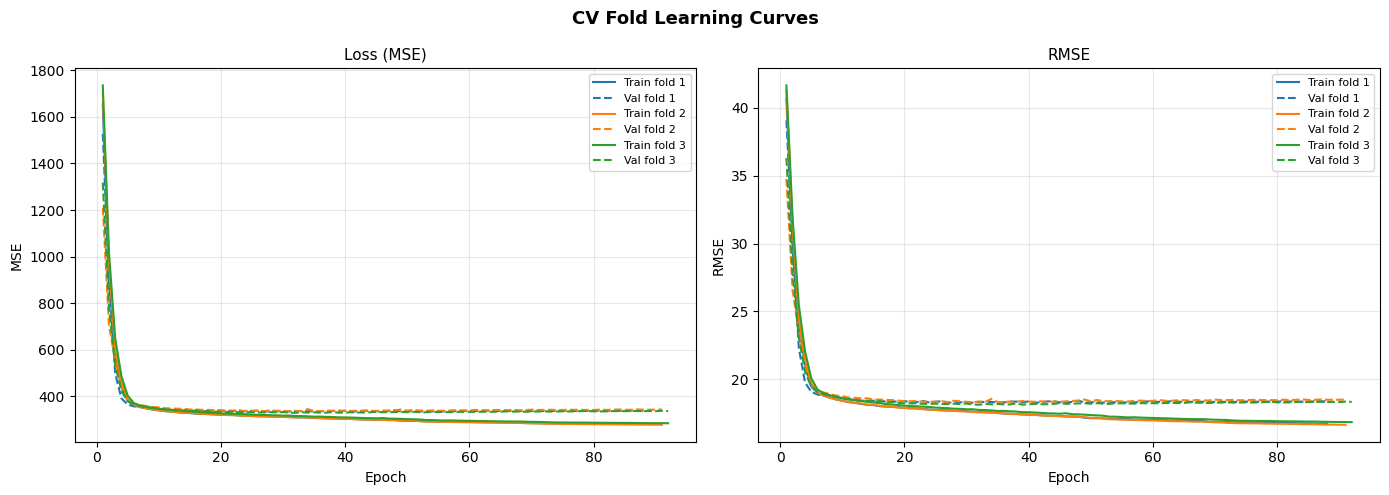

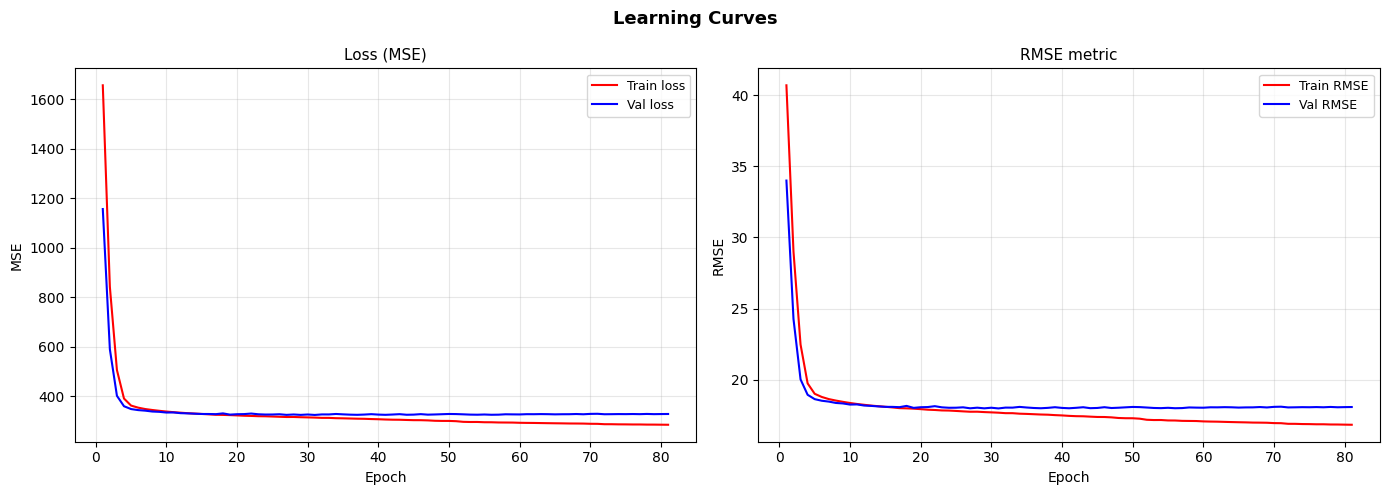

Learning curves:
    Epochs run       : 81
    Final train loss : 284.0813
    Final val loss   : 327.5873
    Best val loss    : 323.7436  (epoch 31)


In [29]:

FOLD_LC_FILE = f"fold_histories.parquet"
LC_FILE    = f"learning_curves.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Fold learning curves
_plot_fold_learning_curves(df_folds)

# Learning curves
_plot_learning_curves(df_lc)

---

## DYJetsToLL

  Loaded 571,928 events from 'predictions_testing_DYJetsToLL.parquet'
  Columns found: ['MET_pt_pred', 'GenMET_pt', 'MET_pt']


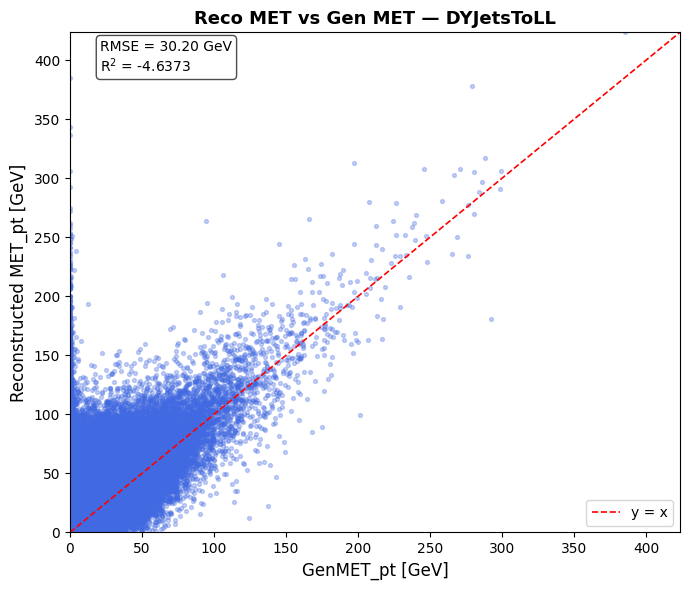

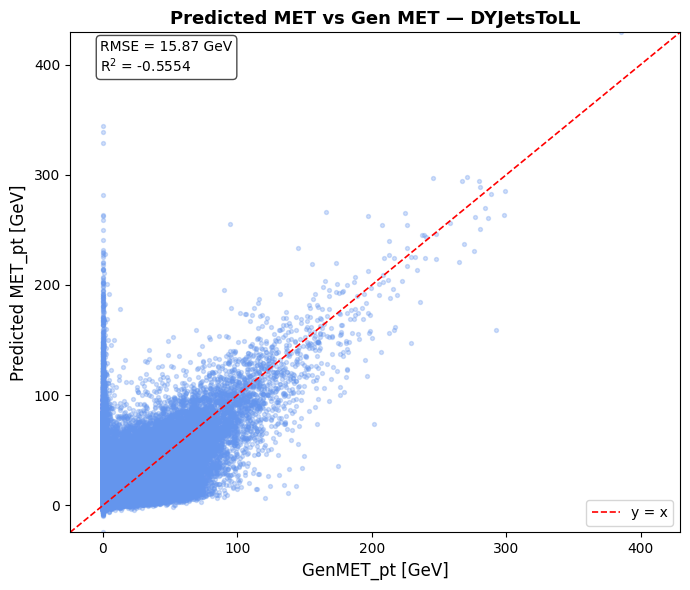

Reconstruction performance for DYJetsToLL:
    RMSE = 30.2043 GeV
    MAE  = 24.7115 GeV
    R²   = -4.6373
ML model performance for DYJetsToLL:
    RMSE = 15.8654 GeV
    MAE  = 11.6104 GeV
    R²   = -0.5554
Performance improvement for DYJetsToLL:
    DELTA_RMSE = 14.3389 GeV
    DELTA_MAE  = 13.1012 GeV
    DELTA_R²   = 4.0819
Performance relative improvement for DYJetsToLL:
    DELTA_RMSE = +47.47%
    DELTA_MAE  = +53.02%
    DELTA_R²   = +88.02%


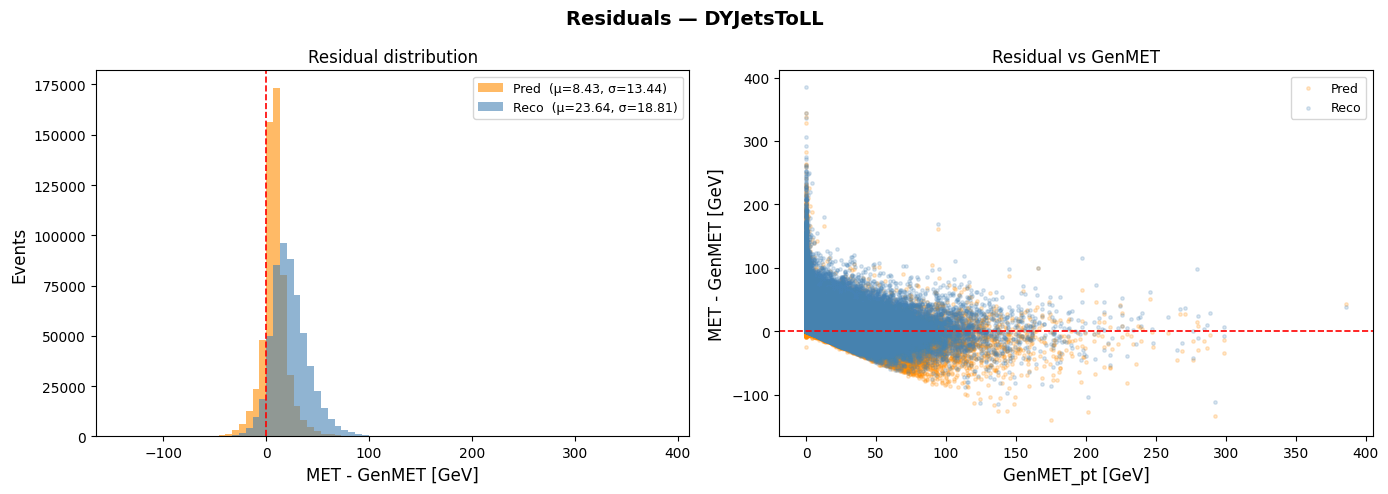

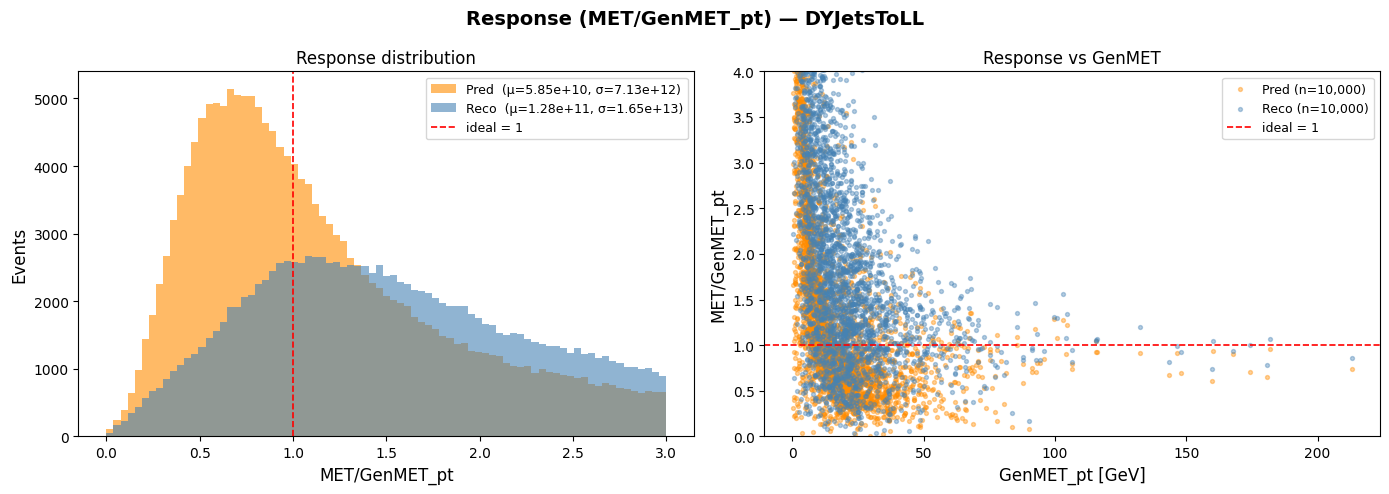

  Plotting up to 220 GeV (last bin with >= 10 events: [210, 220] GeV, n=10)


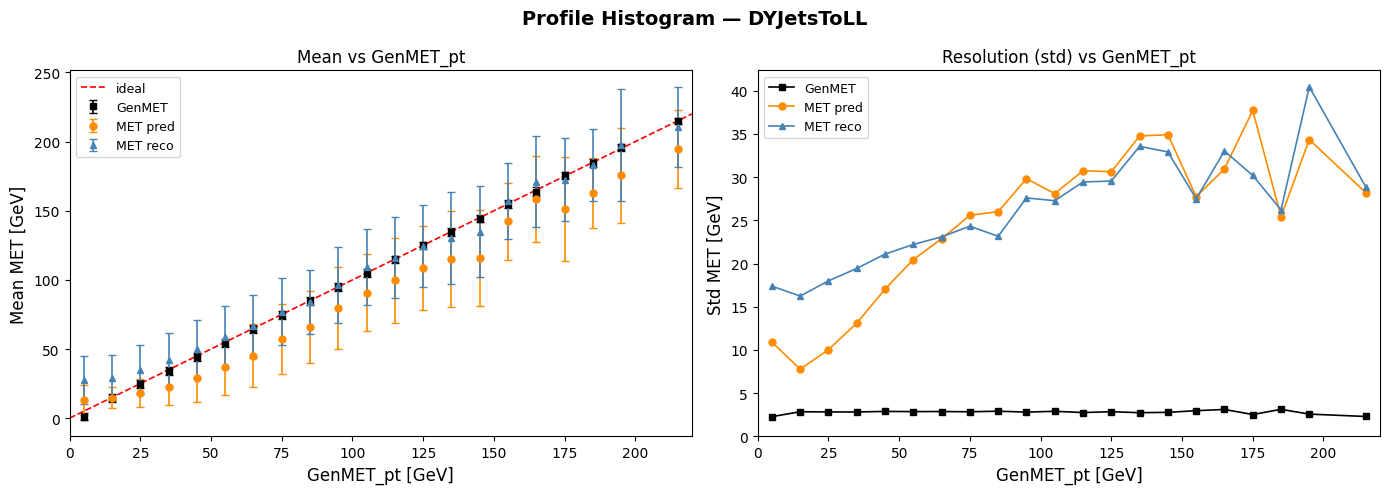

  Excluding GenMET_pt <= 0.001 GeV (305,508 events removed)
  Plotting up to 385.7 GeV (last bin with >= 10 events: [251.2, 385.7] GeV, n=17)


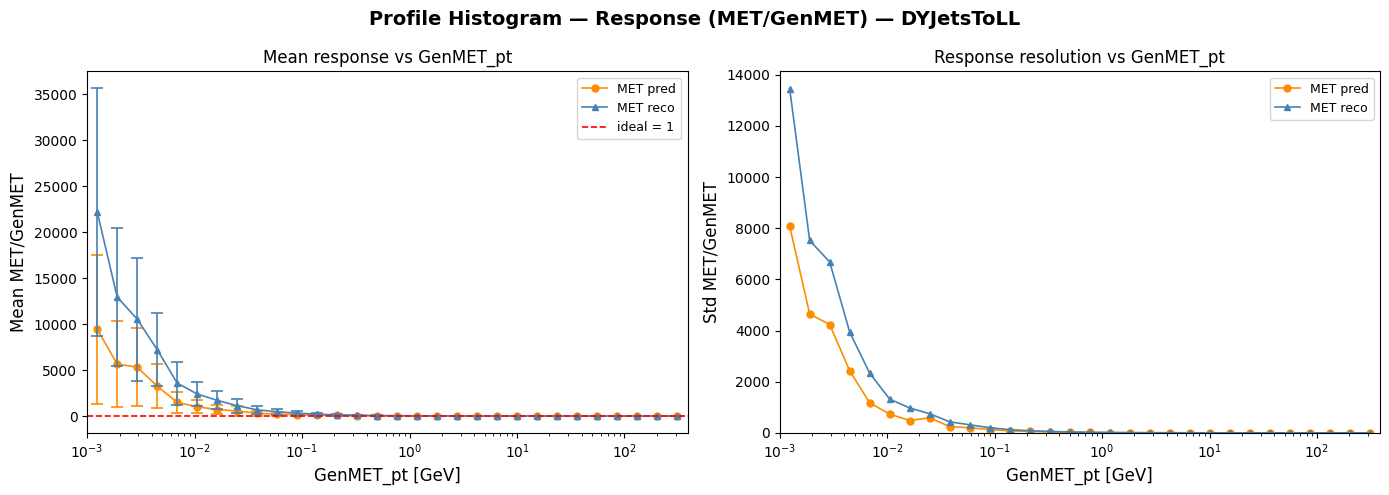

In [30]:
EVENT      = "DYJetsToLL"
PRED_FILE = f"predictions_testing_{EVENT}.parquet"

# Reconstructed/Predicted MET vs GenMET
y_pred, y_true, MET_pt = load_predictions(EVENT)

_scatterplot_reco_vs_gen(MET_pt, y_true, EVENT, color="royalblue")
_scatterplot_pred_vs_gen(y_pred, y_true, EVENT, color="cornflowerblue")

# Performance metrics
_compute_metrics(y_pred, y_true, MET_pt, label=EVENT)

# Residual plot
_residuals_plots(y_pred, y_true, MET_pt, EVENT)

# Response plot
_response_plots(y_pred, y_true, MET_pt, EVENT)

# Profile histogram
_profile_histogram(y_pred, y_true, MET_pt, EVENT, bin_width = 10.0, min_counts = 10)

# Profile histogram response
_profile_histogram_response(y_pred, y_true, MET_pt, EVENT, n_bins = 30, min_counts = 10, min_gen = 1e-3)

---

## HToAATo2Mu2B

  Loaded 198,788 events from 'predictions_testing_HToAATo2Mu2B.parquet'
  Columns found: ['MET_pt_pred', 'GenMET_pt', 'MET_pt']


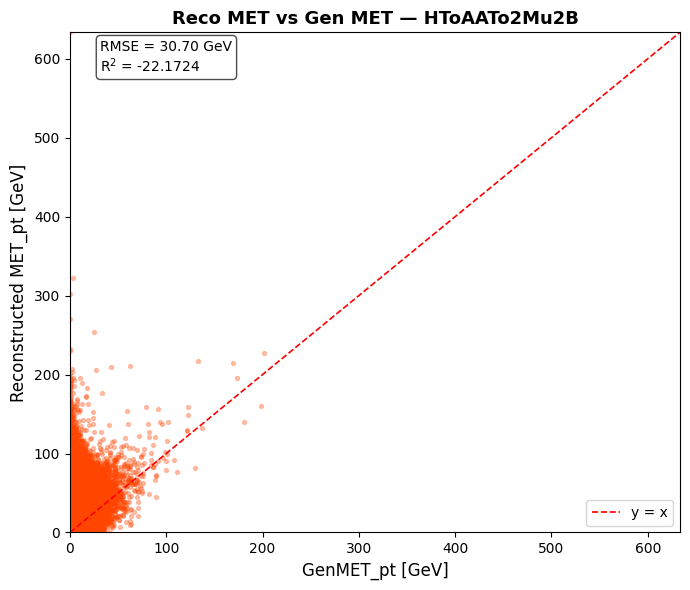

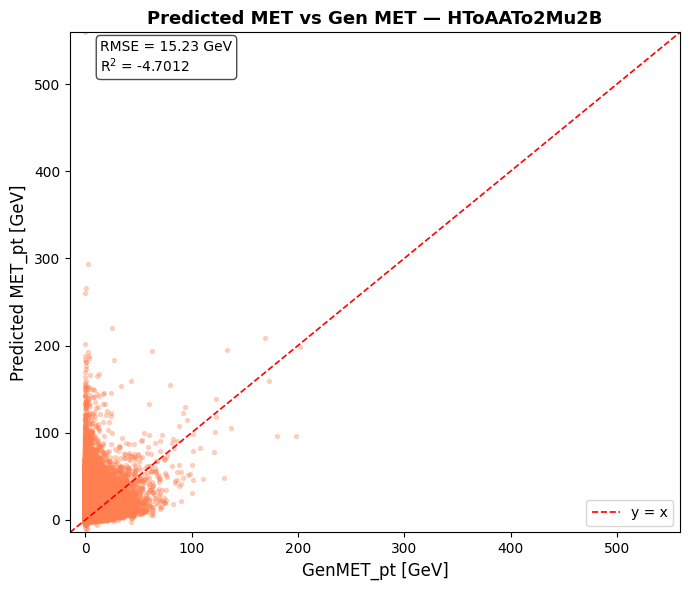

Reconstruction performance for HToAATo2Mu2B:
    RMSE = 30.6970 GeV
    MAE  = 25.0371 GeV
    R²   = -22.1724
ML model performance for HToAATo2Mu2B:
    RMSE = 15.2263 GeV
    MAE  = 10.9170 GeV
    R²   = -4.7012
Performance improvement for HToAATo2Mu2B:
    DELTA_RMSE = 15.4707 GeV
    DELTA_MAE  = 14.1200 GeV
    DELTA_R²   = 17.4712
Performance relative improvement for HToAATo2Mu2B:
    DELTA_RMSE = +50.40%
    DELTA_MAE  = +56.40%
    DELTA_R²   = +78.80%


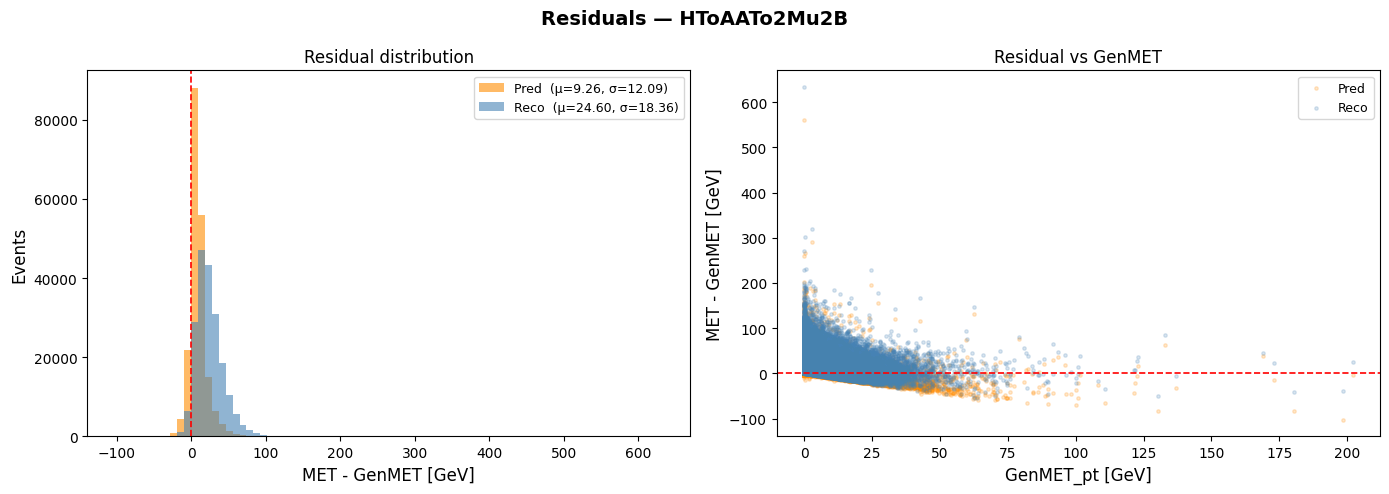

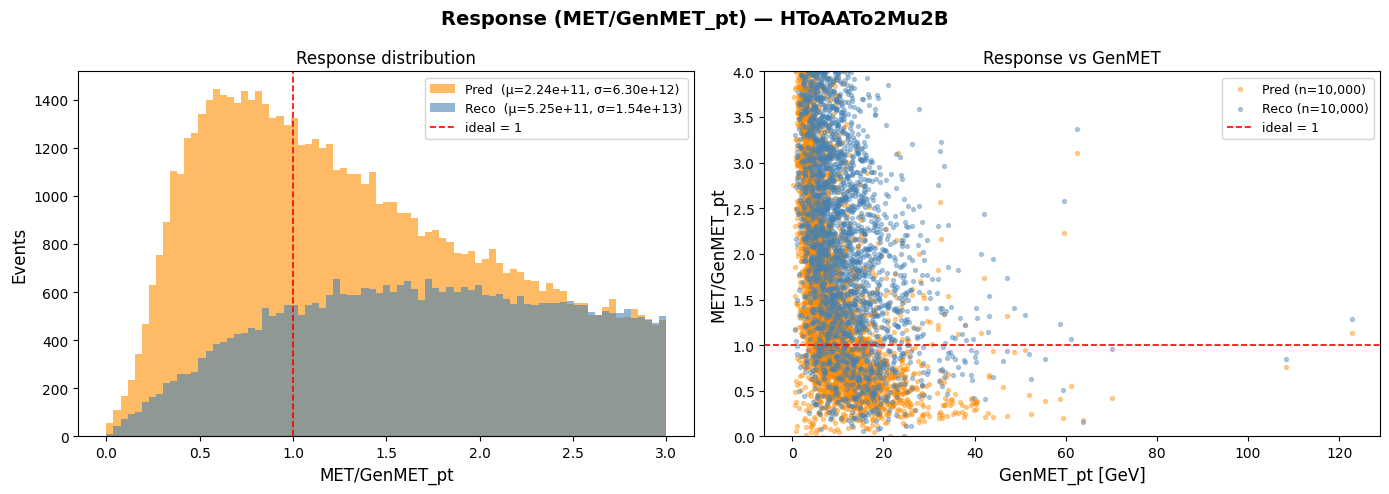

  Plotting up to 90 GeV (last bin with >= 10 events: [80, 90] GeV, n=16)


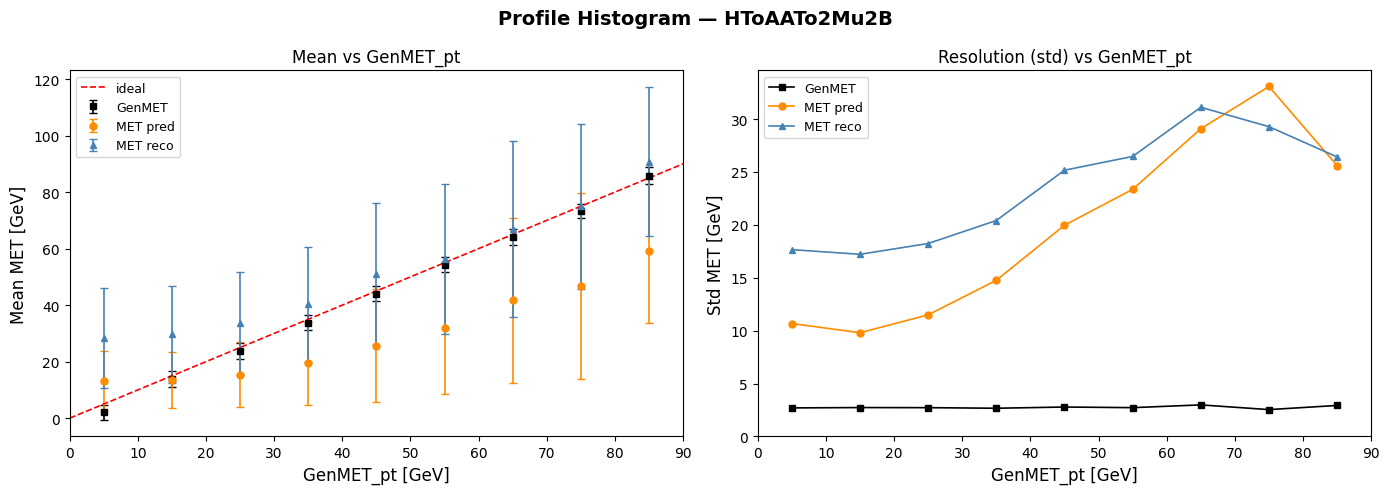

  Excluding GenMET_pt <= 0.001 GeV (61,124 events removed)
  Plotting up to 134.4 GeV (last bin with >= 10 events: [89.5, 134.4] GeV, n=22)


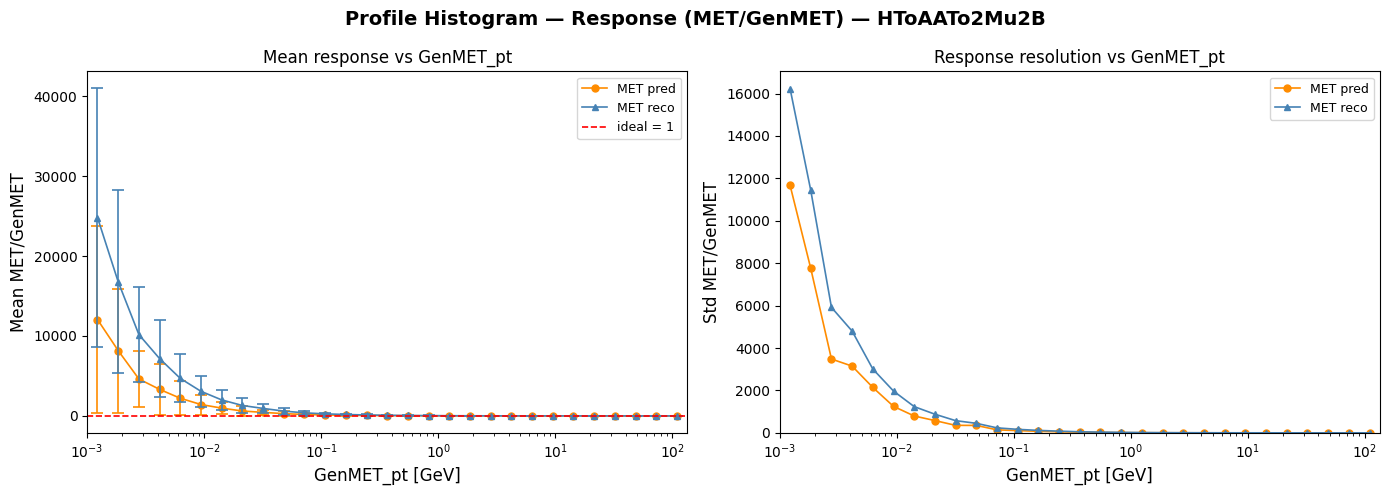

In [31]:
EVENT      = "HToAATo2Mu2B"
PRED_FILE = f"predictions_testing_{EVENT}.parquet"

# Reconstructed/Predicted MET vs GenMET
y_pred, y_true, MET_pt = load_predictions(EVENT)

_scatterplot_reco_vs_gen(MET_pt, y_true, EVENT, color="orangered")
_scatterplot_pred_vs_gen(y_pred, y_true, EVENT, color="coral")

# Performance metrics
_compute_metrics(y_pred, y_true, MET_pt, label=EVENT)

# Residual plot
_residuals_plots(y_pred, y_true, MET_pt, EVENT)

# Response plot
_response_plots(y_pred, y_true, MET_pt, EVENT)

# Profile histogram
_profile_histogram(y_pred, y_true, MET_pt, EVENT, bin_width = 10.0)

# Profile histogram response
_profile_histogram_response(y_pred, y_true, MET_pt, EVENT, n_bins = 30, min_counts = 10, min_gen = 1e-3)

---

## ZZTo2L2Nu

  Loaded 158,930 events from 'predictions_testing_ZZTo2L2Nu.parquet'
  Columns found: ['MET_pt_pred', 'GenMET_pt', 'MET_pt']


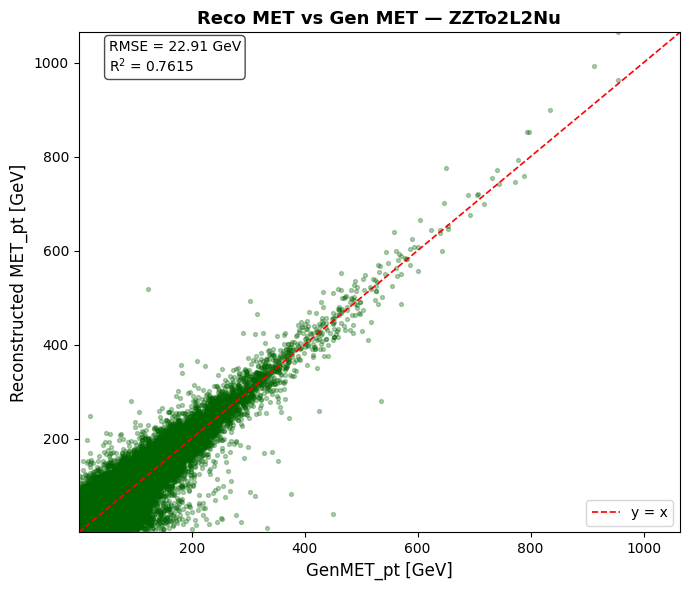

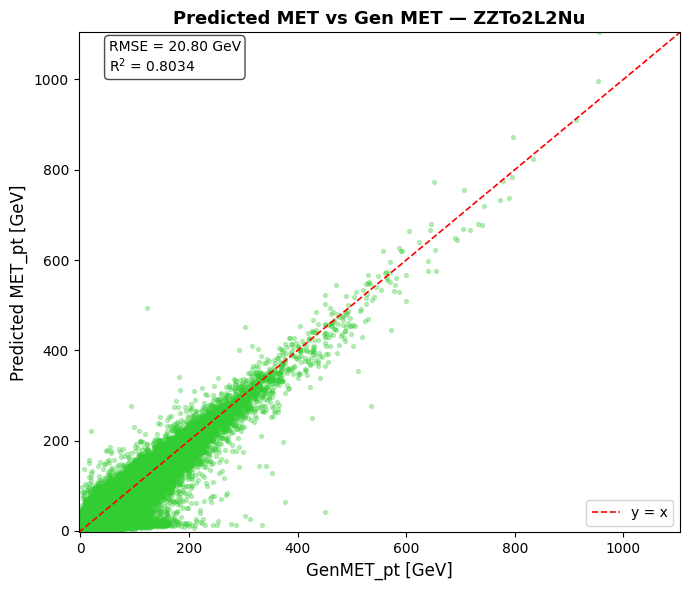

Reconstruction performance for ZZTo2L2Nu:
    RMSE = 22.9067 GeV
    MAE  = 17.2590 GeV
    R²   = 0.7615
ML model performance for ZZTo2L2Nu:
    RMSE = 20.7979 GeV
    MAE  = 14.9315 GeV
    R²   = 0.8034
Performance improvement for ZZTo2L2Nu:
    DELTA_RMSE = 2.1088 GeV
    DELTA_MAE  = 2.3276 GeV
    DELTA_R²   = 0.0419
Performance relative improvement for ZZTo2L2Nu:
    DELTA_RMSE = +9.21%
    DELTA_MAE  = +13.49%
    DELTA_R²   = +5.50%


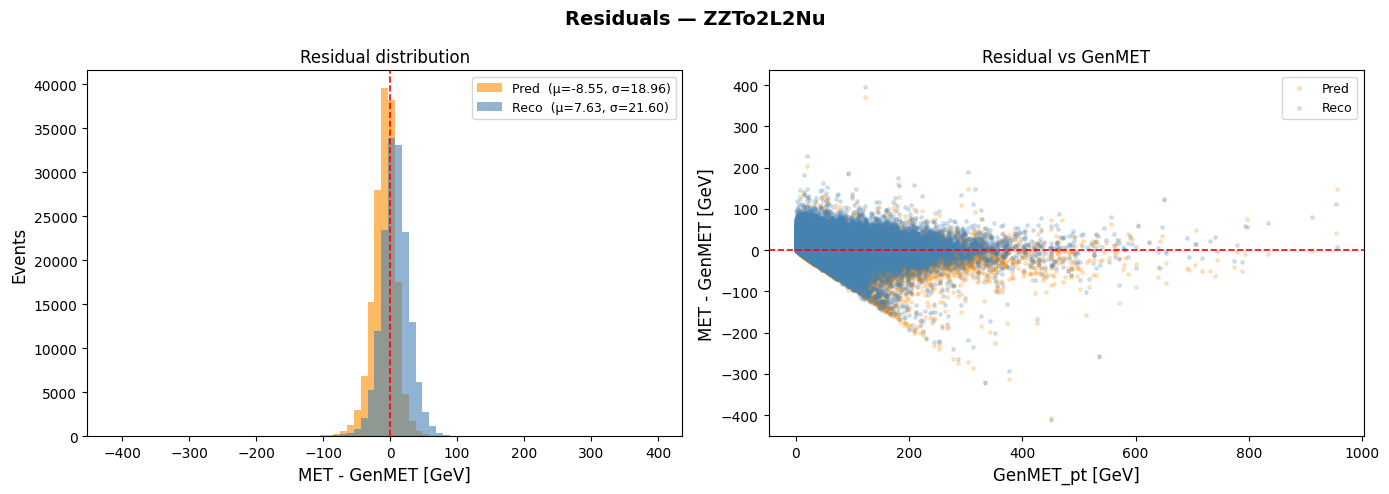

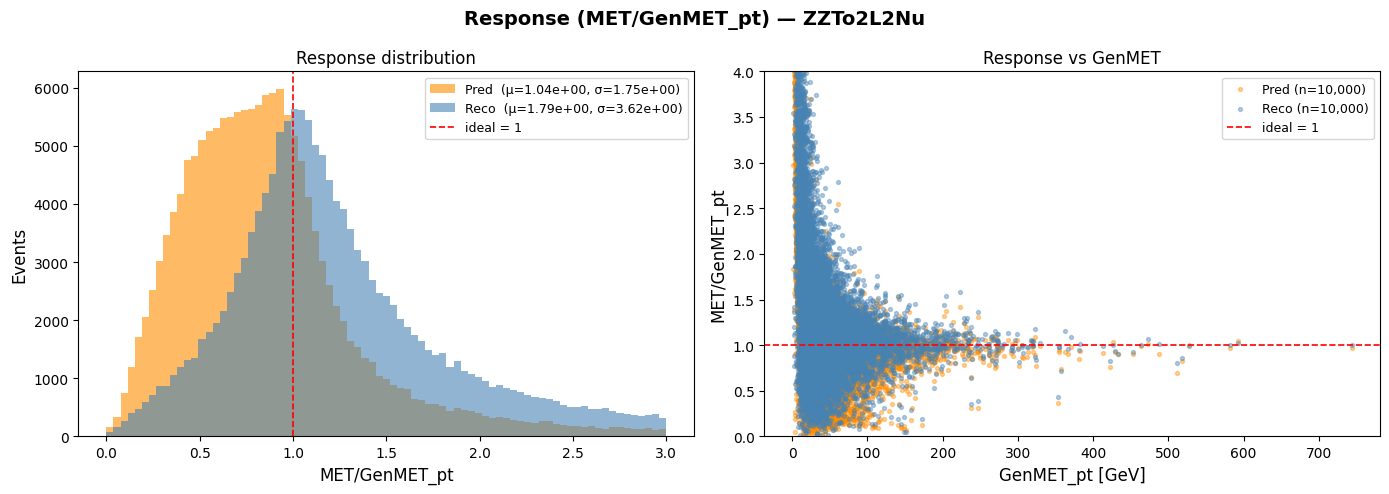

  Plotting up to 490 GeV (last bin with >= 10 events: [480, 490] GeV, n=14)


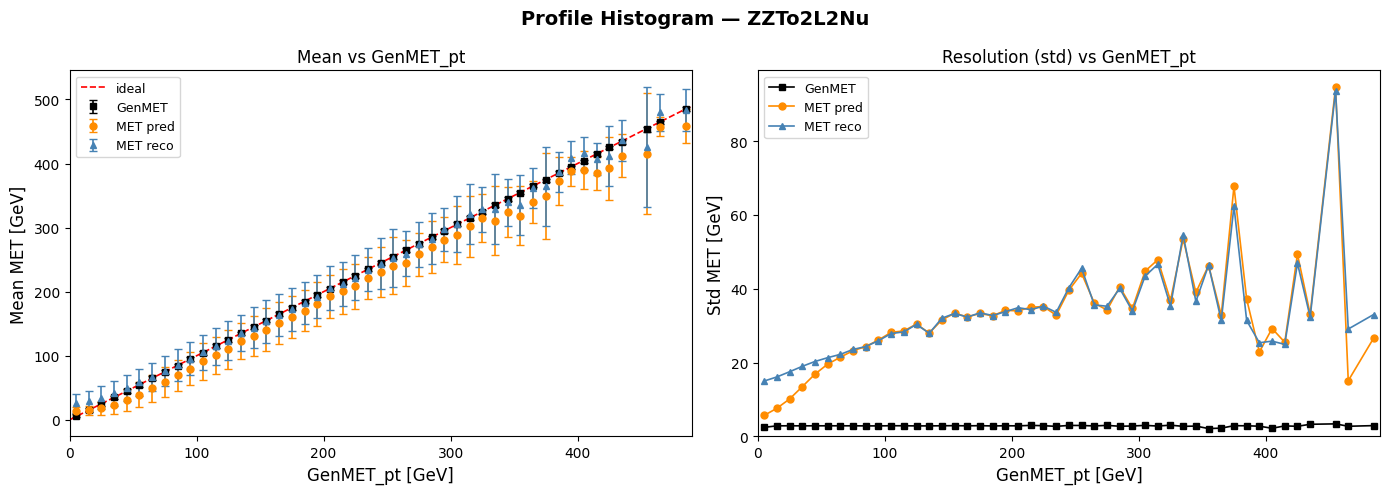

  Excluding GenMET_pt <= 0.1 GeV (2 events removed)
  Plotting up to 955.0 GeV (last bin with >= 10 events: [703.6, 955.0] GeV, n=15)


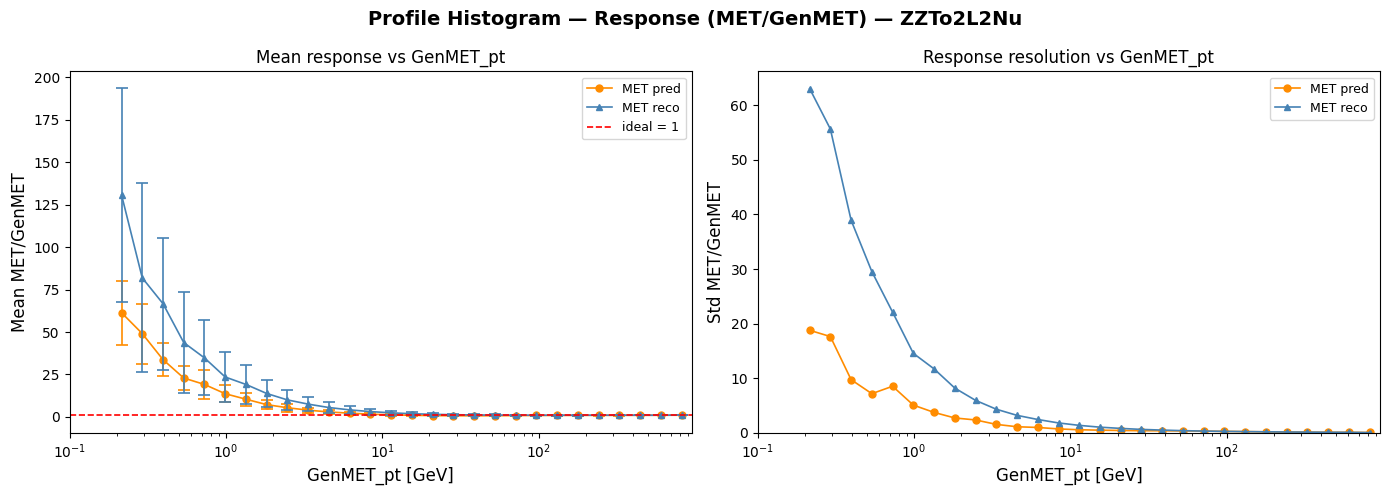

In [32]:
EVENT      = "ZZTo2L2Nu"
PRED_FILE = f"predictions_testing_{EVENT}.parquet"

# Reconstructed/Predicted MET vs GenMET
y_pred, y_true, MET_pt = load_predictions(EVENT)

_scatterplot_reco_vs_gen(MET_pt, y_true, EVENT, color="darkgreen")
_scatterplot_pred_vs_gen(y_pred, y_true, EVENT, color="limegreen")

# Performance metrics
_compute_metrics(y_pred, y_true, MET_pt, label=EVENT)

# Residual plot
_residuals_plots(y_pred, y_true, MET_pt, EVENT)

# Response plot
_response_plots(y_pred, y_true, MET_pt, EVENT)

# Profile histogram
_profile_histogram(y_pred, y_true, MET_pt, EVENT, bin_width = 10.0)

# Profile histogram response
_profile_histogram_response(y_pred, y_true, MET_pt, EVENT, n_bins = 30, min_counts = 10, min_gen = 1e-1)